<a href="https://colab.research.google.com/github/justamy20/midterm-machine-learning/blob/main/clustering_customer_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 Customer Credit Card Clustering — End-to-End ML Pipeline
**UTS Machine Learning — Individual Task**

| Field | Detail |
|-------|--------|
| **Nama** | Syeh Khatami |
| **NIM** | 101032300157 |
| **Kelas** | Machine Learning |

---

**Deskripsi Dataset:**
`clusteringmidterm.csv` berisi data penggunaan kartu kredit pelanggan: balance, pembelian, cash advance, frekuensi transaksi, limit kredit, pembayaran, dll.

**Pipeline:**
1. Setup & Load Dataset (Google Drive)
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Menentukan Jumlah Cluster Optimal
5. Training Model Clustering (K-Means, Hierarchical, DBSCAN)
6. Evaluasi Cluster
7. Interpretasi & Profil Tiap Cluster
8. Visualisasi (PCA, t-SNE)
9. Kesimpulan

## ⚙️ 1. Install Library & Mount Google Drive

In [3]:
!pip install -q mlflow yellowbrick

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [4]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive berhasil di-mount!')

Mounted at /content/drive
✅ Google Drive berhasil di-mount!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering Models
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import silhouette_samples

# Visualization
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# Tracking
import mlflow

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


## 📂 2. Load Dataset

> **Cara upload:**
> 1. Buka drive.google.com
> 2. Buat folder `clustering_dataset`
> 3. Upload `clusteringmidterm.csv` ke folder tersebut

In [6]:
# ============================================================
# SESUAIKAN PATH INI
# ============================================================
DATA_PATH = '/content/drive/MyDrive/clustering_dataset/clusteringmidterm.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Kolom: {df_raw.columns.tolist()}')
df_raw.head()

Shape: (8950, 18)
Kolom: ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 🔎 3. Exploratory Data Analysis (EDA)

In [7]:
# Statistik deskriptif
print('=== Info Dataset ===')
print(f'Jumlah pelanggan : {df_raw.shape[0]:,}')
print(f'Jumlah fitur     : {df_raw.shape[1]}')
print(f'\nMissing Values:')
missing = df_raw.isnull().sum()
print(missing[missing > 0])
print(f'\nStatistik Deskriptif:')
df_raw.describe().round(2)

=== Info Dataset ===
Jumlah pelanggan : 8,950
Jumlah fitur     : 18

Missing Values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Statistik Deskriptif:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8949.00,8950.00,8637.00,8950.00,8950.00
mean,1564.47,0.88,1003.20,592.44,411.07,978.87,0.49,0.20,0.36,0.14,3.25,14.71,4494.45,1733.14,864.21,0.15,11.52
std,2081.53,0.24,2136.63,1659.89,904.34,2097.16,0.40,0.30,0.40,0.20,6.82,24.86,3638.82,2895.06,2372.45,0.29,1.34
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.00,0.00,0.02,0.00,6.00
25%,128.28,0.89,39.64,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.00,1.00,1600.00,383.28,169.12,0.00,12.00
50%,873.39,1.00,361.28,38.00,89.00,0.00,0.50,0.08,0.17,0.00,0.00,7.00,3000.00,856.90,312.34,0.00,12.00
75%,2054.14,1.00,1110.13,577.40,468.64,1113.82,0.92,0.30,0.75,0.22,4.00,17.00,6500.00,1901.13,825.49,0.14,12.00
max,19043.14,1.00,49039.57,40761.25,22500.00,47137.21,1.00,1.00,1.00,1.50,123.00,358.00,30000.00,50721.48,76406.21,1.00,12.00


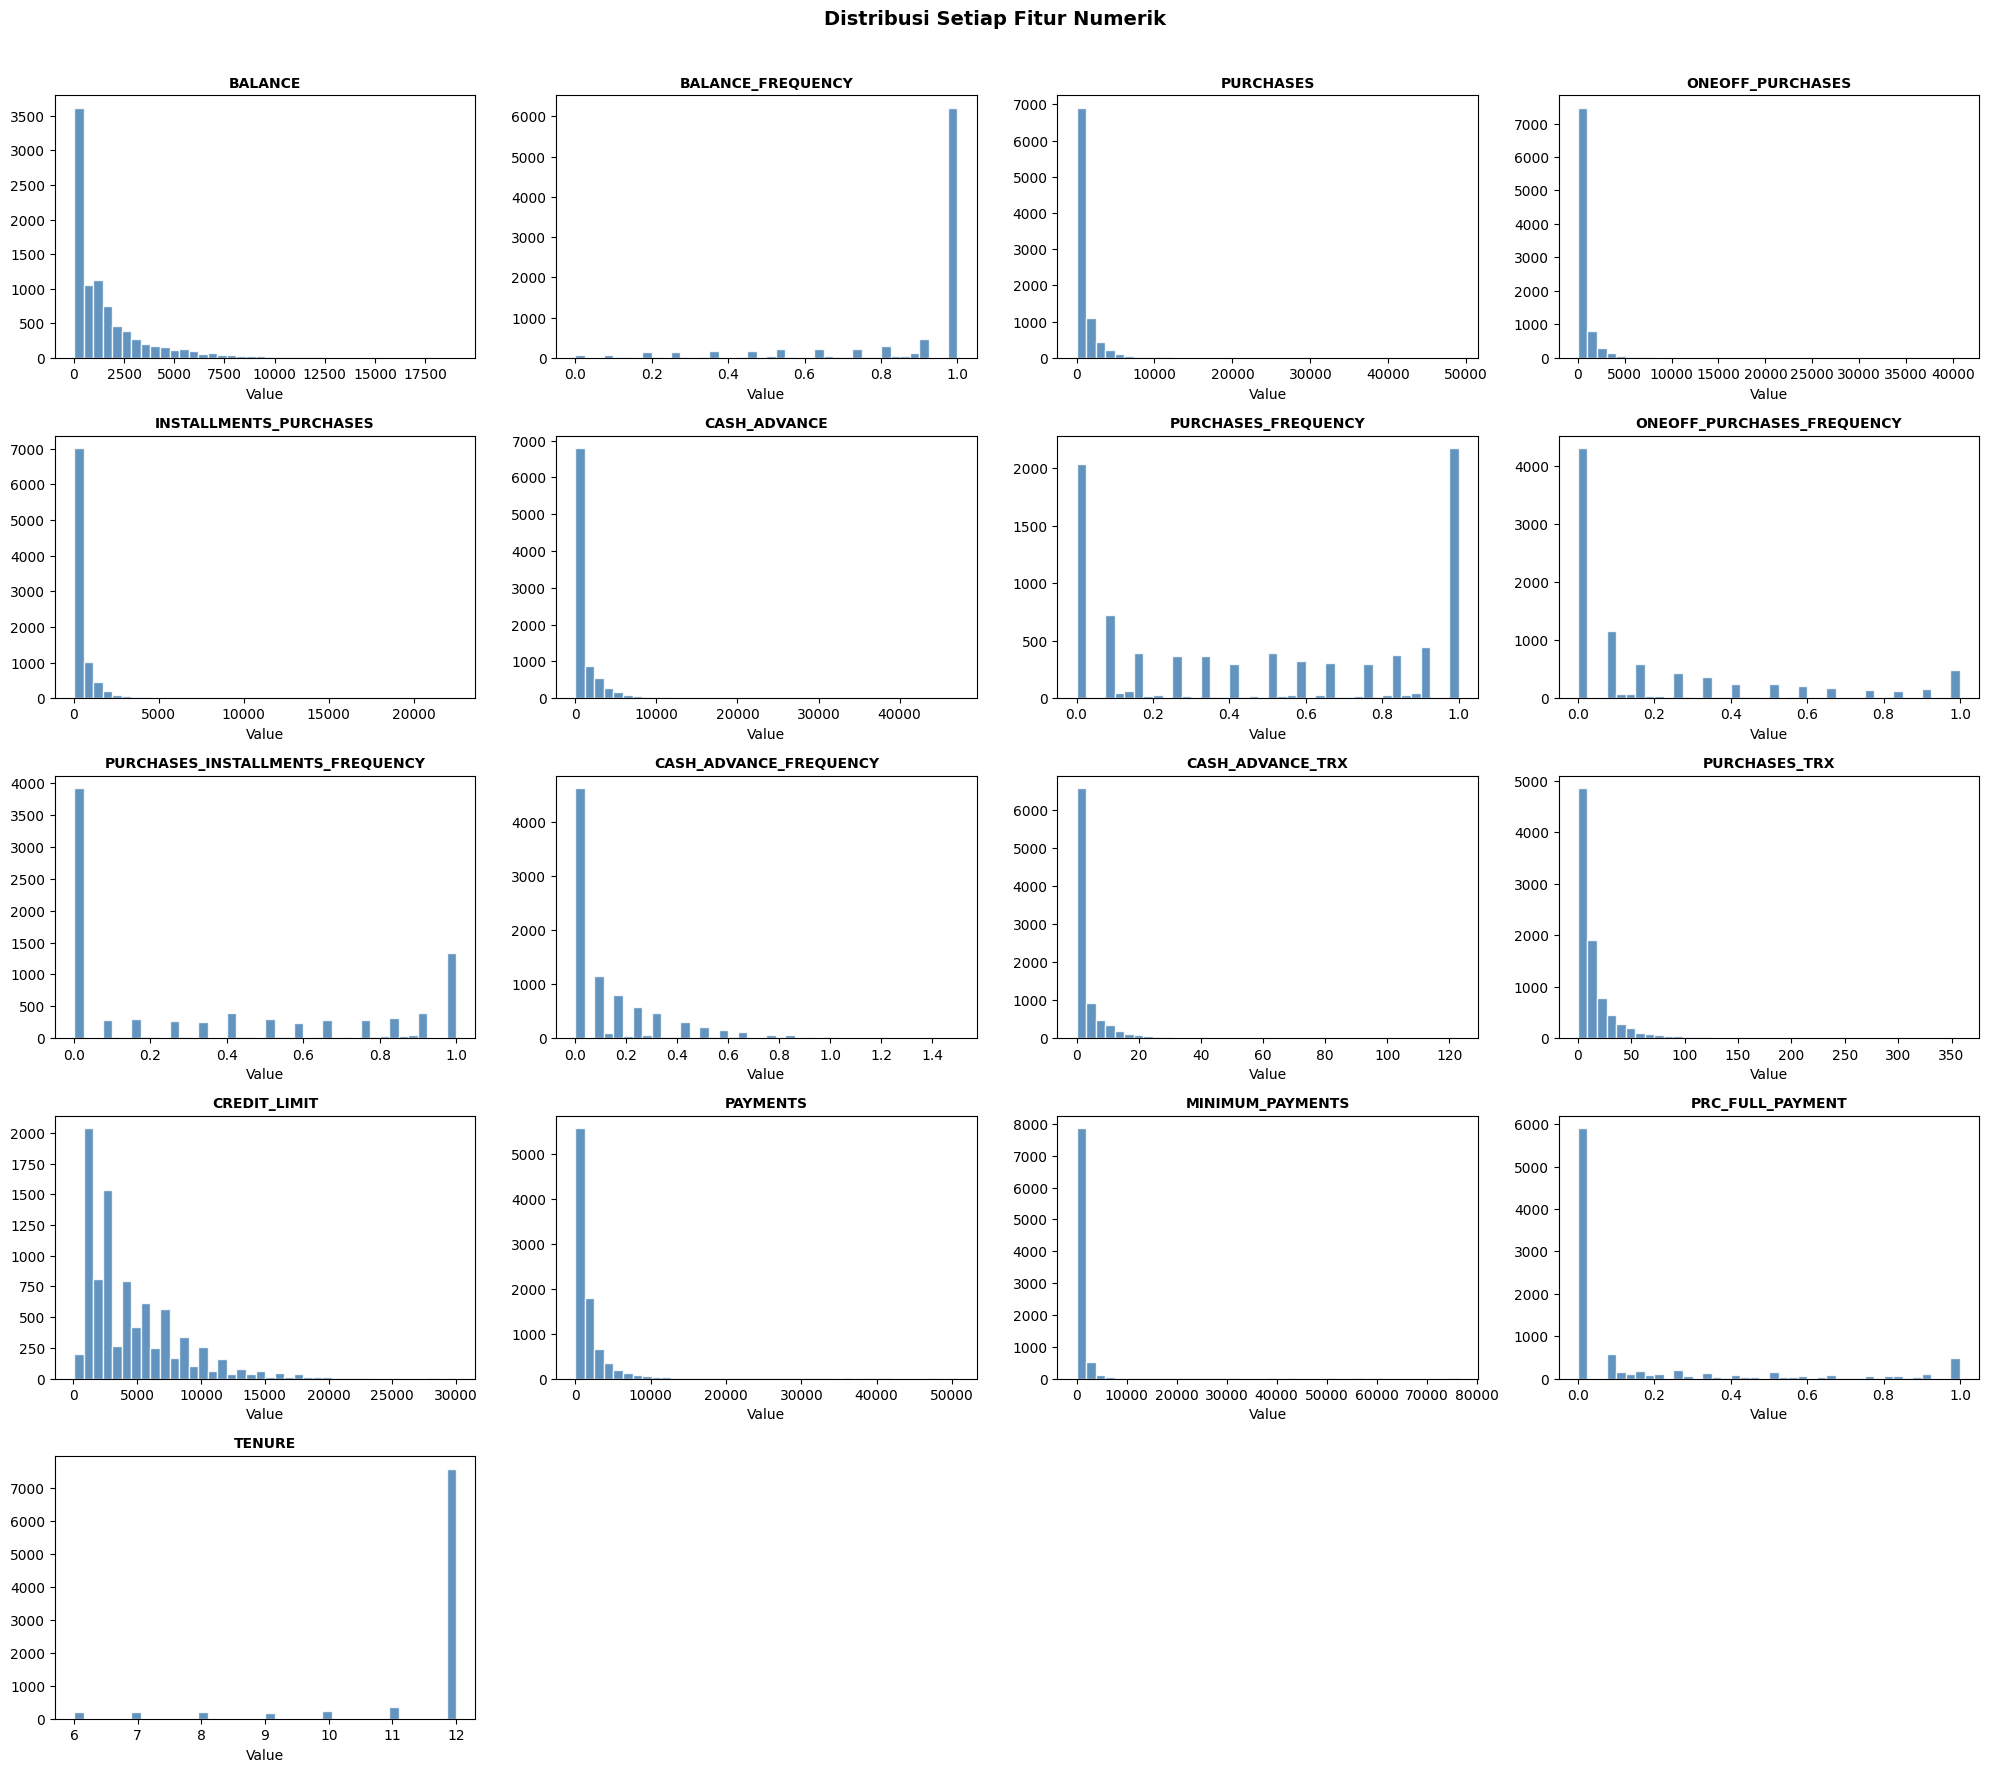

In [8]:
# Distribusi setiap fitur numerik
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
n        = len(num_cols)
ncols    = 4
nrows    = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_raw[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Setiap Fitur Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

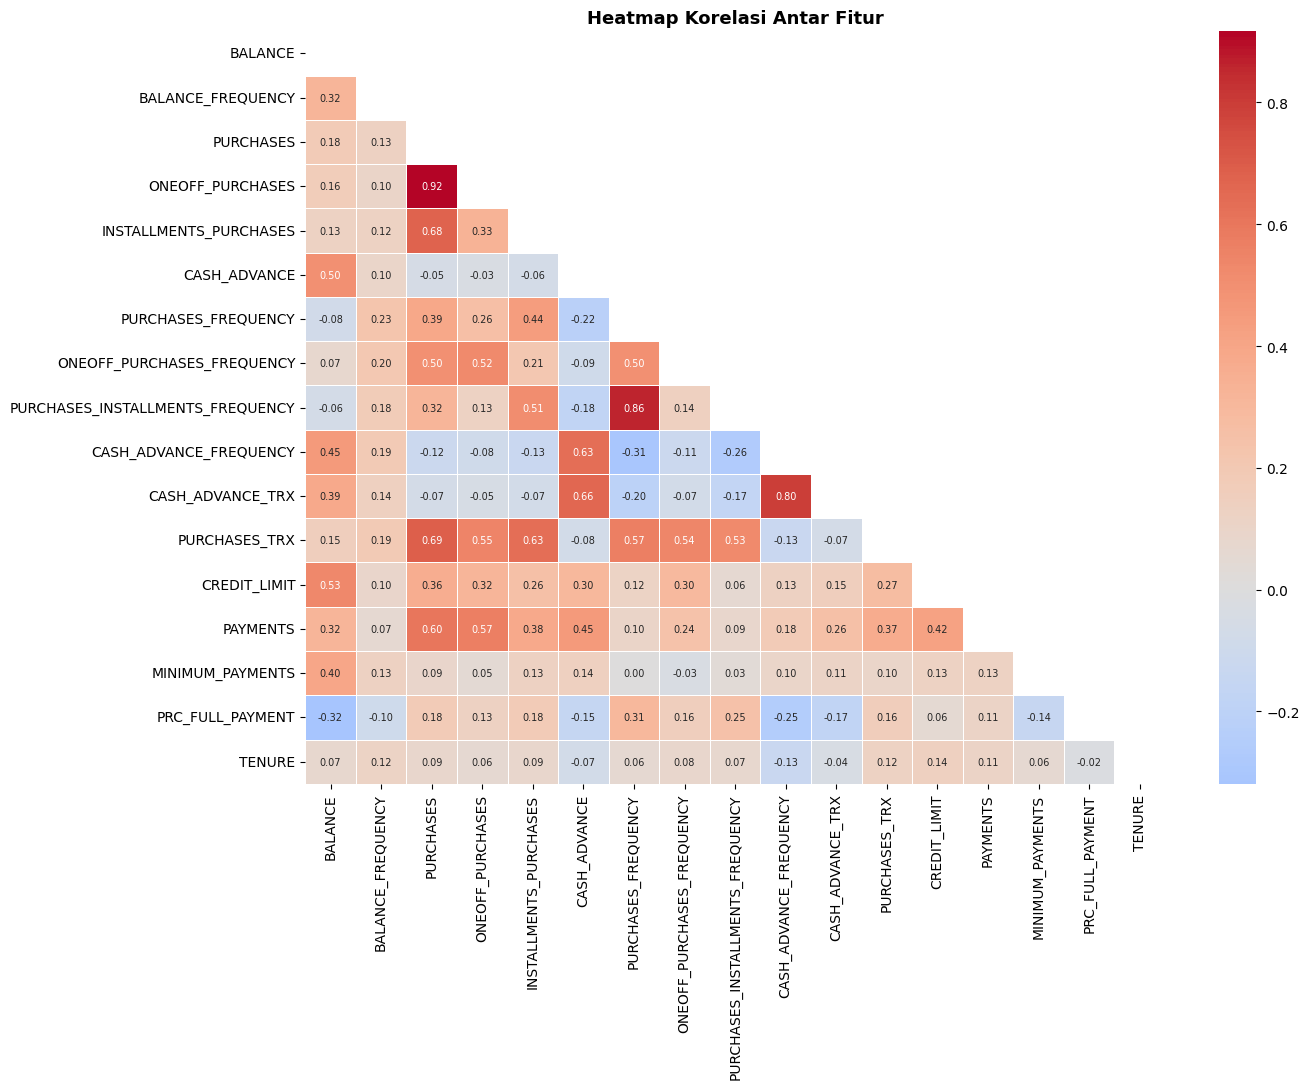

In [9]:
# Heatmap korelasi antar fitur
fig, ax = plt.subplots(figsize=(14, 11))
corr = df_raw[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax,
            linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

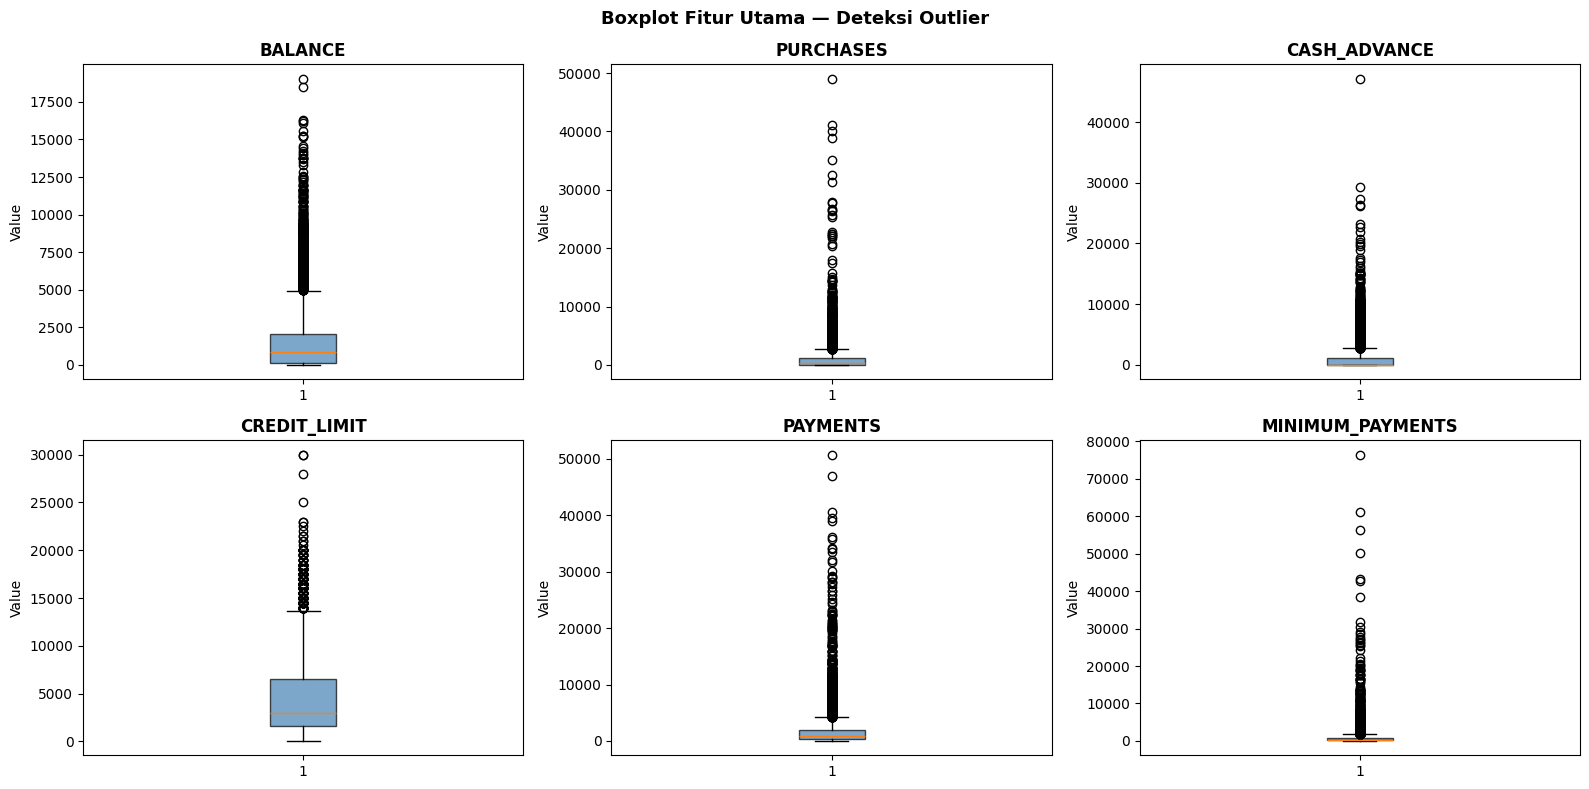

In [10]:
# Boxplot untuk deteksi outlier
key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
            'PAYMENTS', 'MINIMUM_PAYMENTS']
key_cols = [c for c in key_cols if c in df_raw.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_cols[:6]):
    axes[i].boxplot(df_raw[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')
plt.suptitle('Boxplot Fitur Utama — Deteksi Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=100, bbox_inches='tight')
plt.show()

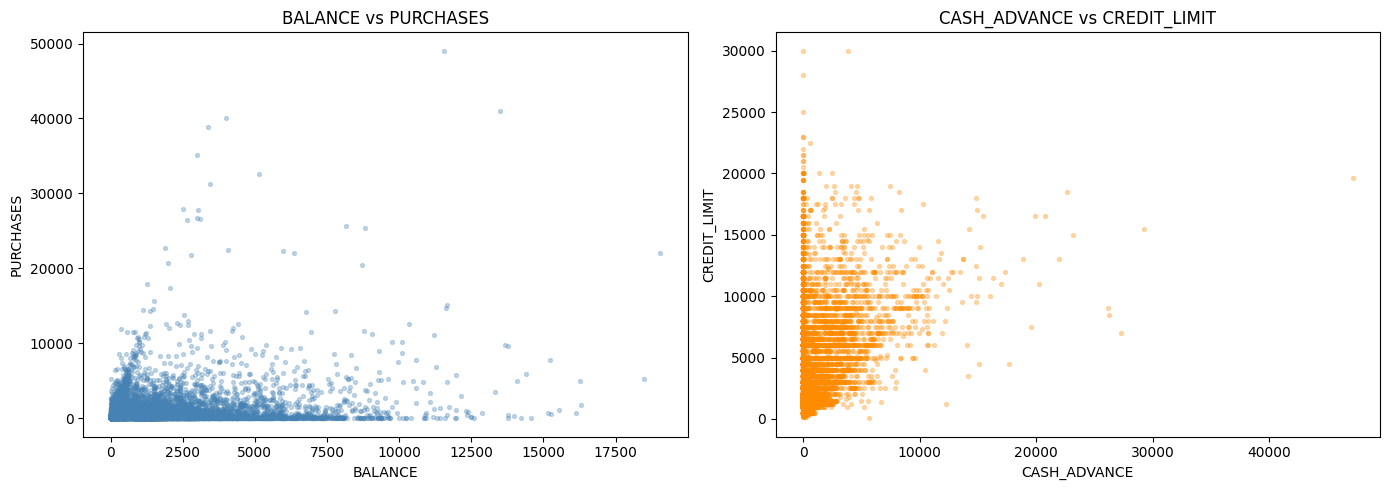

In [11]:
# Scatter plot BALANCE vs PURCHASES (colored later by cluster)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'BALANCE' in df_raw.columns and 'PURCHASES' in df_raw.columns:
    axes[0].scatter(df_raw['BALANCE'], df_raw['PURCHASES'],
                    alpha=0.3, s=8, color='steelblue')
    axes[0].set_xlabel('BALANCE')
    axes[0].set_ylabel('PURCHASES')
    axes[0].set_title('BALANCE vs PURCHASES')

if 'CASH_ADVANCE' in df_raw.columns and 'CREDIT_LIMIT' in df_raw.columns:
    axes[1].scatter(df_raw['CASH_ADVANCE'], df_raw['CREDIT_LIMIT'],
                    alpha=0.3, s=8, color='darkorange')
    axes[1].set_xlabel('CASH_ADVANCE')
    axes[1].set_ylabel('CREDIT_LIMIT')
    axes[1].set_title('CASH_ADVANCE vs CREDIT_LIMIT')

plt.tight_layout()
plt.savefig('scatter_eda.png', dpi=100, bbox_inches='tight')
plt.show()

## 🛠️ 4. Preprocessing & Feature Engineering

In [12]:
# 4.1 Drop kolom ID (bukan fitur)
ID_COL = 'CUST_ID'
if ID_COL in df_raw.columns:
    cust_ids = df_raw[ID_COL].copy()
    df = df_raw.drop(columns=[ID_COL])
    print(f'✅ Drop kolom ID: {ID_COL}')
else:
    df = df_raw.copy()

print(f'Shape setelah drop ID: {df.shape}')

✅ Drop kolom ID: CUST_ID
Shape setelah drop ID: (8950, 17)


In [13]:
# 4.2 Impute missing values (median)
imputer  = SimpleImputer(strategy='median')
df_imp   = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print(f'✅ Imputation selesai. Missing tersisa: {df_imp.isnull().sum().sum()}')

✅ Imputation selesai. Missing tersisa: 0


In [14]:
# 4.3 Feature Engineering — tambah fitur turunan yang informatif
df_feat = df_imp.copy()

# Rasio pembayaran vs balance
if 'PAYMENTS' in df_feat.columns and 'BALANCE' in df_feat.columns:
    df_feat['PAYMENT_RATIO'] = df_feat['PAYMENTS'] / (df_feat['BALANCE'] + 1)
    print('✅ Tambah: PAYMENT_RATIO')

# Rasio cash advance vs total spending
if 'CASH_ADVANCE' in df_feat.columns and 'PURCHASES' in df_feat.columns:
    total = df_feat['CASH_ADVANCE'] + df_feat['PURCHASES'] + 1
    df_feat['CASH_ADVANCE_RATIO'] = df_feat['CASH_ADVANCE'] / total
    print('✅ Tambah: CASH_ADVANCE_RATIO')

# Utilisasi kredit
if 'BALANCE' in df_feat.columns and 'CREDIT_LIMIT' in df_feat.columns:
    df_feat['CREDIT_UTILIZATION'] = df_feat['BALANCE'] / (df_feat['CREDIT_LIMIT'] + 1)
    print('✅ Tambah: CREDIT_UTILIZATION')

# Rata-rata pembelian per transaksi
if 'PURCHASES' in df_feat.columns and 'PURCHASES_TRX' in df_feat.columns:
    df_feat['AVG_PURCHASE_PER_TRX'] = df_feat['PURCHASES'] / (df_feat['PURCHASES_TRX'] + 1)
    print('✅ Tambah: AVG_PURCHASE_PER_TRX')

print(f'\nShape setelah feature engineering: {df_feat.shape}')

✅ Tambah: PAYMENT_RATIO
✅ Tambah: CASH_ADVANCE_RATIO
✅ Tambah: CREDIT_UTILIZATION
✅ Tambah: AVG_PURCHASE_PER_TRX

Shape setelah feature engineering: (8950, 21)


In [15]:
# 4.4 Handle outlier (IQR clip)
df_clean = df_feat.copy()
for col in df_clean.columns:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = df_clean[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print('✅ Outlier di-clip (IQR method)')

✅ Outlier di-clip (IQR method)


In [16]:
# 4.5 Standardisasi (WAJIB untuk clustering berbasis jarak)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
X_scaled = pd.DataFrame(X_scaled, columns=df_clean.columns)
print(f'✅ StandardScaler selesai. Shape: {X_scaled.shape}')
print(f'   Mean ~ 0: {X_scaled.mean().abs().max():.4f}')
print(f'   Std  ~ 1: {X_scaled.std().mean():.4f}')

✅ StandardScaler selesai. Shape: (8950, 21)
   Mean ~ 0: 0.0000
   Std  ~ 1: 0.9524


## 🔢 5. Menentukan Jumlah Cluster Optimal

In [17]:
# ============================================================
# 5.1 Elbow Method
# ============================================================
inertias   = []
sil_scores = []
db_scores  = []
ch_scores  = []
K_range    = range(2, 11)

print('Menghitung Elbow + Silhouette untuk K=2 s.d. 10...')
for k in K_range:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))
    db_scores.append(davies_bouldin_score(X_scaled, lbl))
    ch_scores.append(calinski_harabasz_score(X_scaled, lbl))
    print(f'  K={k}: Inertia={km.inertia_:.0f} | Silhouette={sil_scores[-1]:.4f}')

print('✅ Selesai!')

Menghitung Elbow + Silhouette untuk K=2 s.d. 10...
  K=2: Inertia=136041 | Silhouette=0.2270
  K=3: Inertia=111818 | Silhouette=0.2274
  K=4: Inertia=101255 | Silhouette=0.1852
  K=5: Inertia=92270 | Silhouette=0.1886
  K=6: Inertia=85764 | Silhouette=0.1850
  K=7: Inertia=80552 | Silhouette=0.1848
  K=8: Inertia=76917 | Silhouette=0.1843
  K=9: Inertia=73534 | Silhouette=0.1852
  K=10: Inertia=70800 | Silhouette=0.1792
✅ Selesai!


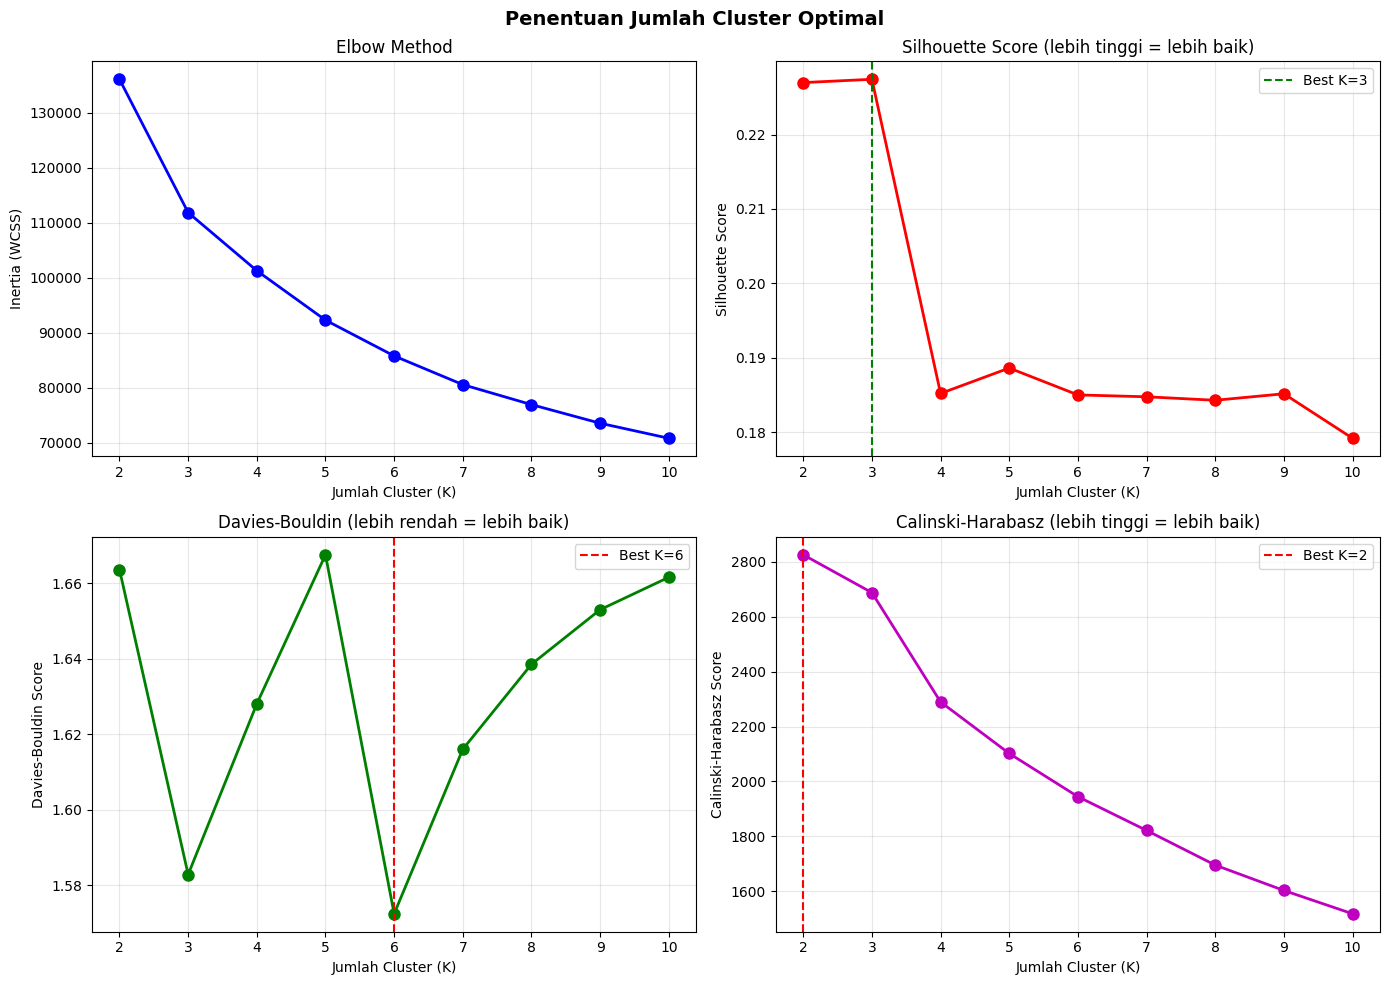

Rekomendasi K berdasarkan Silhouette   : 3
Rekomendasi K berdasarkan Davies-Bouldin: 6
Rekomendasi K berdasarkan Calinski-H   : 2


In [18]:
# Visualisasi Elbow + Silhouette + Davies-Bouldin + Calinski-Harabasz
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
K_list = list(K_range)

# Elbow
axes[0,0].plot(K_list, inertias, 'bo-', lw=2, markersize=8)
axes[0,0].set_xlabel('Jumlah Cluster (K)')
axes[0,0].set_ylabel('Inertia (WCSS)')
axes[0,0].set_title('Elbow Method')
axes[0,0].grid(alpha=0.3)

# Silhouette
best_k_sil = K_list[np.argmax(sil_scores)]
axes[0,1].plot(K_list, sil_scores, 'ro-', lw=2, markersize=8)
axes[0,1].axvline(best_k_sil, color='green', linestyle='--',
                   label=f'Best K={best_k_sil}')
axes[0,1].set_xlabel('Jumlah Cluster (K)')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].set_title('Silhouette Score (lebih tinggi = lebih baik)')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Davies-Bouldin
best_k_db = K_list[np.argmin(db_scores)]
axes[1,0].plot(K_list, db_scores, 'go-', lw=2, markersize=8)
axes[1,0].axvline(best_k_db, color='red', linestyle='--',
                   label=f'Best K={best_k_db}')
axes[1,0].set_xlabel('Jumlah Cluster (K)')
axes[1,0].set_ylabel('Davies-Bouldin Score')
axes[1,0].set_title('Davies-Bouldin (lebih rendah = lebih baik)')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Calinski-Harabasz
best_k_ch = K_list[np.argmax(ch_scores)]
axes[1,1].plot(K_list, ch_scores, 'mo-', lw=2, markersize=8)
axes[1,1].axvline(best_k_ch, color='red', linestyle='--',
                   label=f'Best K={best_k_ch}')
axes[1,1].set_xlabel('Jumlah Cluster (K)')
axes[1,1].set_ylabel('Calinski-Harabasz Score')
axes[1,1].set_title('Calinski-Harabasz (lebih tinggi = lebih baik)')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimal_k.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Rekomendasi K berdasarkan Silhouette   : {best_k_sil}')
print(f'Rekomendasi K berdasarkan Davies-Bouldin: {best_k_db}')
print(f'Rekomendasi K berdasarkan Calinski-H   : {best_k_ch}')

K optimal yang dipilih: 3


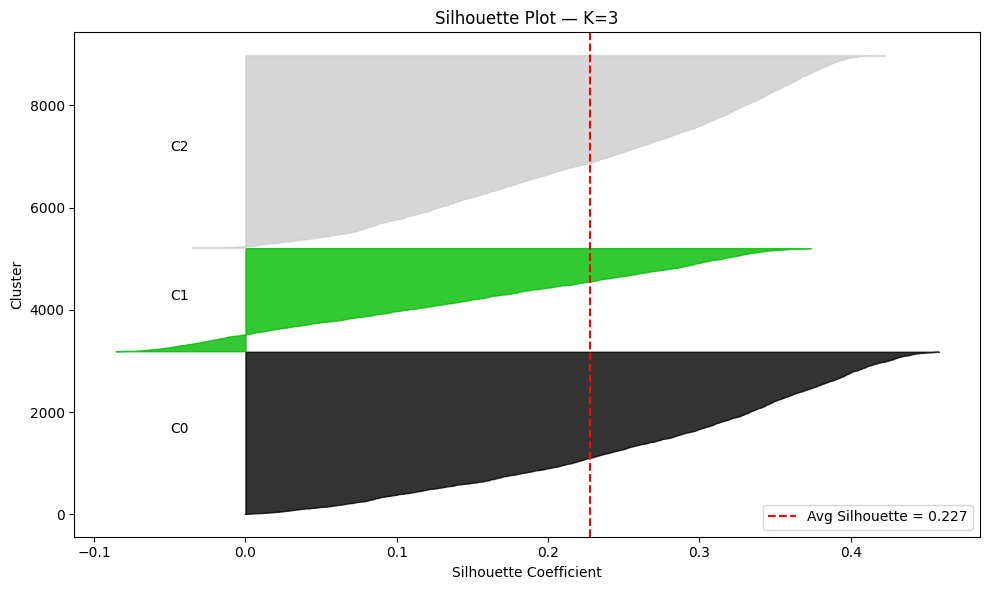

In [19]:
# ============================================================
# 5.2 Silhouette Plot untuk K optimal
# ============================================================
# Pilih K berdasarkan silhouette score tertinggi
OPTIMAL_K = best_k_sil
print(f'K optimal yang dipilih: {OPTIMAL_K}')

km_opt = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
labels_opt = km_opt.fit_predict(X_scaled)

sample_sil  = silhouette_samples(X_scaled, labels_opt)
fig, ax     = plt.subplots(figsize=(10, 6))
y_lower     = 10
colors_sil  = cm.nipy_spectral(np.linspace(0, 1, OPTIMAL_K))

for i in range(OPTIMAL_K):
    ith_sil  = np.sort(sample_sil[labels_opt == i])
    size_i   = ith_sil.shape[0]
    y_upper  = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=colors_sil[i], edgecolor=colors_sil[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size_i, f'C{i}')
    y_lower  = y_upper + 10

avg_sil = silhouette_score(X_scaled, labels_opt)
ax.axvline(avg_sil, color='red', linestyle='--',
           label=f'Avg Silhouette = {avg_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — K={OPTIMAL_K}')
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=100, bbox_inches='tight')
plt.show()

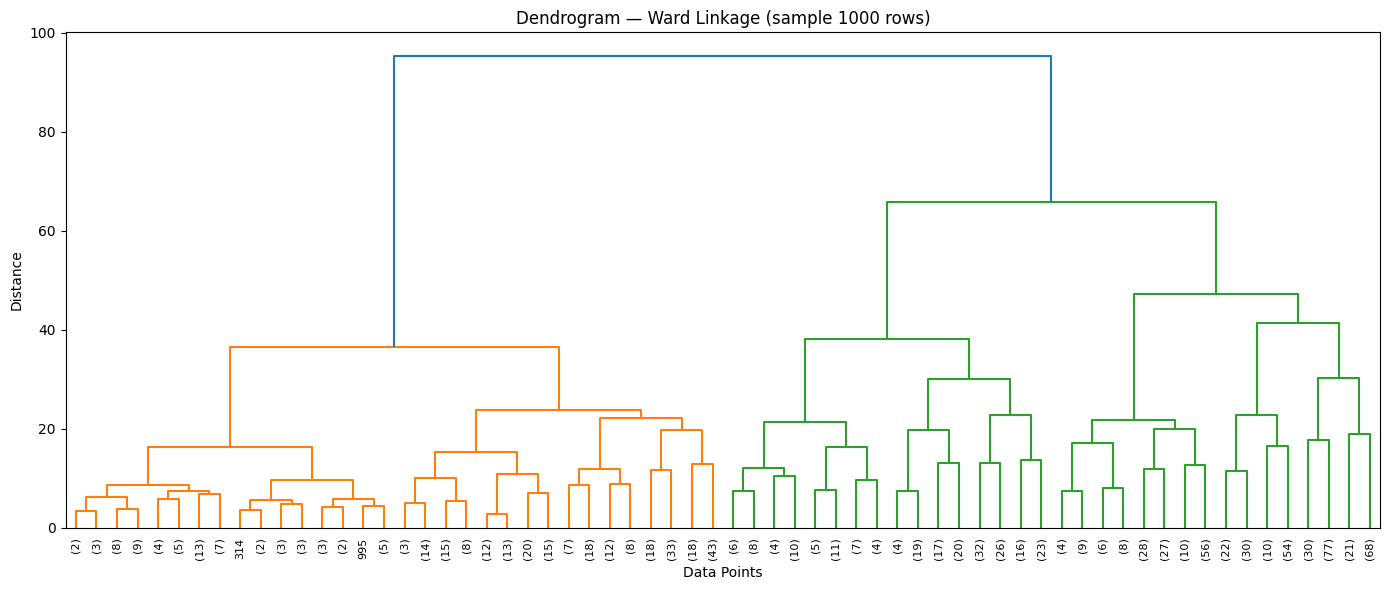

In [20]:
# ============================================================
# 5.3 Dendrogram (Hierarchical Clustering)
# ============================================================
# Ambil sample agar cepat (max 1000 baris)
sample_size = min(1000, len(X_scaled))
X_sample    = X_scaled.sample(sample_size, random_state=42)

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7*max(Z[:,2]))
ax.set_title(f'Dendrogram — Ward Linkage (sample {sample_size} rows)')
ax.set_xlabel('Data Points')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=100, bbox_inches='tight')
plt.show()

## 🤖 6. Training Model Clustering + MLflow Tracking

In [21]:
# Setup MLflow
mlflow.set_experiment('customer_clustering_UTS')

def evaluate_clustering(labels, X, model_name, params=None):
    """Hitung dan log metrik clustering ke MLflow."""
    # Filter label noise (-1 dari DBSCAN)
    mask    = labels != -1
    n_clust = len(set(labels[mask]))

    if n_clust < 2:
        print(f'⚠️ {model_name}: hanya {n_clust} cluster valid — skip evaluasi')
        return None

    sil = silhouette_score(X[mask], labels[mask])
    db  = davies_bouldin_score(X[mask], labels[mask])
    ch  = calinski_harabasz_score(X[mask], labels[mask])
    n_noise = (labels == -1).sum()

    with mlflow.start_run(run_name=model_name):
        mlflow.log_param('model', model_name)
        if params: mlflow.log_params(params)
        mlflow.log_metrics({
            'silhouette_score'     : sil,
            'davies_bouldin_score' : db,
            'calinski_harabasz'    : ch,
            'n_clusters'           : n_clust,
            'n_noise_points'       : int(n_noise)
        })

    print(f'\n📊 {model_name}')
    print(f'  Jumlah cluster   : {n_clust}')
    print(f'  Silhouette Score : {sil:.4f}  (↑ lebih baik, max=1)')
    print(f'  Davies-Bouldin   : {db:.4f}  (↓ lebih baik, min=0)')
    print(f'  Calinski-Harabasz: {ch:.2f} (↑ lebih baik)')
    if n_noise > 0:
        print(f'  Noise points     : {n_noise} ({n_noise/len(labels)*100:.1f}%)')

    return {'Model': model_name, 'N_Clusters': n_clust,
            'Silhouette': sil, 'Davies_Bouldin': db,
            'Calinski_Harabasz': ch, 'Noise_Points': int(n_noise)}

print('✅ Fungsi evaluasi clustering siap!')

2026/05/15 11:44:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 11:44:38 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 11:44:40 INFO mlflow.tracking.fluent: Experiment with name 'customer_clustering_UTS' does not exist. Creating a new experiment.


✅ Fungsi evaluasi clustering siap!


In [22]:
# ============================================================
# Model 1: K-Means (K optimal)
# ============================================================
km_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++',
                   n_init=10, random_state=42)
labels_km = km_final.fit_predict(X_scaled)

results = []
r = evaluate_clustering(labels_km, X_scaled.values, f'KMeans_K{OPTIMAL_K}',
                         {'n_clusters': OPTIMAL_K, 'init': 'k-means++'})
if r: results.append(r)


📊 KMeans_K3
  Jumlah cluster   : 3
  Silhouette Score : 0.2274  (↑ lebih baik, max=1)
  Davies-Bouldin   : 1.5828  (↓ lebih baik, min=0)
  Calinski-Harabasz: 2687.77 (↑ lebih baik)


In [23]:
# ============================================================
# Model 2: K-Means variasi K (K-1 dan K+1)
# ============================================================
for k_var in [max(2, OPTIMAL_K-1), OPTIMAL_K+1]:
    km_v  = KMeans(n_clusters=k_var, init='k-means++', n_init=10, random_state=42)
    lbl_v = km_v.fit_predict(X_scaled)
    r = evaluate_clustering(lbl_v, X_scaled.values, f'KMeans_K{k_var}',
                             {'n_clusters': k_var})
    if r: results.append(r)


📊 KMeans_K2
  Jumlah cluster   : 2
  Silhouette Score : 0.2270  (↑ lebih baik, max=1)
  Davies-Bouldin   : 1.6637  (↓ lebih baik, min=0)
  Calinski-Harabasz: 2825.60 (↑ lebih baik)

📊 KMeans_K4
  Jumlah cluster   : 4
  Silhouette Score : 0.1852  (↑ lebih baik, max=1)
  Davies-Bouldin   : 1.6281  (↓ lebih baik, min=0)
  Calinski-Harabasz: 2289.62 (↑ lebih baik)


In [24]:
# ============================================================
# Model 3: Hierarchical Clustering (Agglomerative)
# ============================================================
for linkage_m in ['ward', 'complete', 'average']:
    agg  = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage=linkage_m)
    lbl_agg = agg.fit_predict(X_scaled)
    r = evaluate_clustering(lbl_agg, X_scaled.values,
                             f'Hierarchical_{linkage_m}',
                             {'n_clusters': OPTIMAL_K, 'linkage': linkage_m})
    if r: results.append(r)


📊 Hierarchical_ward
  Jumlah cluster   : 3
  Silhouette Score : 0.1941  (↑ lebih baik, max=1)
  Davies-Bouldin   : 1.7276  (↓ lebih baik, min=0)
  Calinski-Harabasz: 2192.10 (↑ lebih baik)

📊 Hierarchical_complete
  Jumlah cluster   : 3
  Silhouette Score : 0.1431  (↑ lebih baik, max=1)
  Davies-Bouldin   : 1.8233  (↓ lebih baik, min=0)
  Calinski-Harabasz: 1422.56 (↑ lebih baik)

📊 Hierarchical_average
  Jumlah cluster   : 3
  Silhouette Score : 0.1640  (↑ lebih baik, max=1)
  Davies-Bouldin   : 1.8022  (↓ lebih baik, min=0)
  Calinski-Harabasz: 996.82 (↑ lebih baik)


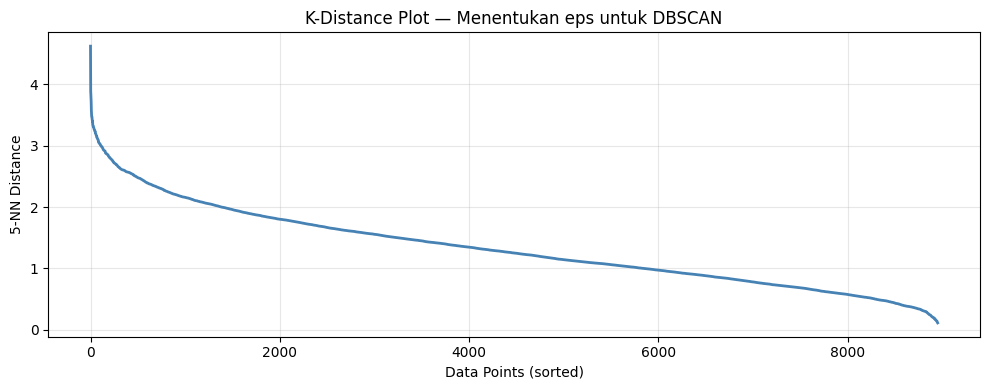

eps yang dipilih (persentil 10%): 0.5591
Cluster ditemukan DBSCAN: 43
Noise points: 7690

📊 DBSCAN
  Jumlah cluster   : 43
  Silhouette Score : 0.2623  (↑ lebih baik, max=1)
  Davies-Bouldin   : 0.7184  (↓ lebih baik, min=0)
  Calinski-Harabasz: 456.06 (↑ lebih baik)
  Noise points     : 7690 (85.9%)


In [25]:
# ============================================================
# Model 4: DBSCAN
# ============================================================
# Cari eps optimal dengan k-distance plot
from sklearn.neighbors import NearestNeighbors

nn  = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
dists, _ = nn.kneighbors(X_scaled)
k_dists  = np.sort(dists[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dists, color='steelblue', lw=2)
ax.set_xlabel('Data Points (sorted)')
ax.set_ylabel('5-NN Distance')
ax.set_title('K-Distance Plot — Menentukan eps untuk DBSCAN')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kdistance_plot.png', dpi=100, bbox_inches='tight')
plt.show()

# Ambil persentil sebagai eps
eps_val = np.percentile(k_dists, 10)
print(f'eps yang dipilih (persentil 10%): {eps_val:.4f}')

dbscan  = DBSCAN(eps=eps_val, min_samples=5)
lbl_db  = dbscan.fit_predict(X_scaled)
print(f'Cluster ditemukan DBSCAN: {len(set(lbl_db)) - (1 if -1 in lbl_db else 0)}')
print(f'Noise points: {(lbl_db == -1).sum()}')

r = evaluate_clustering(lbl_db, X_scaled.values, 'DBSCAN',
                         {'eps': eps_val, 'min_samples': 5})
if r: results.append(r)

## 📊 7. Evaluasi & Perbandingan Model Clustering

In [26]:
# Tabel perbandingan
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Silhouette', ascending=False).reset_index(drop=True)
print('=== 🏆 Perbandingan Semua Model Clustering ===')
print(df_results.round(4).to_string(index=False))

=== 🏆 Perbandingan Semua Model Clustering ===
                Model  N_Clusters  Silhouette  Davies_Bouldin  Calinski_Harabasz  Noise_Points
               DBSCAN          43      0.2623          0.7184           456.0575          7690
            KMeans_K3           3      0.2274          1.5828          2687.7734             0
            KMeans_K2           2      0.2270          1.6637          2825.5963             0
    Hierarchical_ward           3      0.1941          1.7276          2192.0950             0
            KMeans_K4           4      0.1852          1.6281          2289.6227             0
 Hierarchical_average           3      0.1640          1.8022           996.8239             0
Hierarchical_complete           3      0.1431          1.8233          1422.5559             0


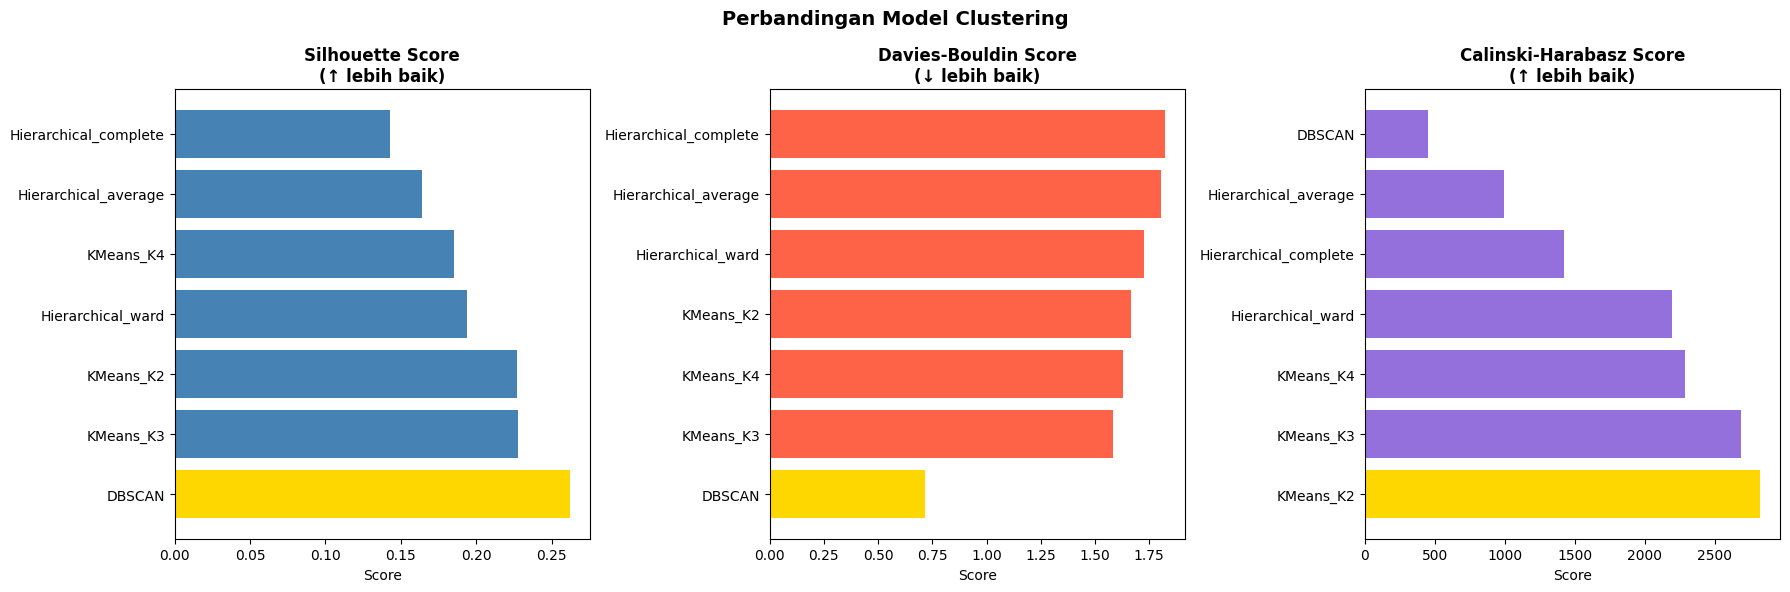

In [27]:
# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['gold' if i == 0 else 'steelblue' for i in range(len(df_results))]

# Silhouette (higher better)
bars = axes[0].barh(df_results['Model'], df_results['Silhouette'], color=colors)
axes[0].set_title('Silhouette Score\n(↑ lebih baik)', fontweight='bold')
axes[0].set_xlabel('Score')

# Davies-Bouldin (lower better)
sorted_db = df_results.sort_values('Davies_Bouldin')
c2 = ['gold' if i == 0 else 'tomato' for i in range(len(sorted_db))]
axes[1].barh(sorted_db['Model'], sorted_db['Davies_Bouldin'], color=c2)
axes[1].set_title('Davies-Bouldin Score\n(↓ lebih baik)', fontweight='bold')
axes[1].set_xlabel('Score')

# Calinski-Harabasz (higher better)
sorted_ch = df_results.sort_values('Calinski_Harabasz', ascending=False)
c3 = ['gold' if i == 0 else 'mediumpurple' for i in range(len(sorted_ch))]
axes[2].barh(sorted_ch['Model'], sorted_ch['Calinski_Harabasz'], color=c3)
axes[2].set_title('Calinski-Harabasz Score\n(↑ lebih baik)', fontweight='bold')
axes[2].set_xlabel('Score')

plt.suptitle('Perbandingan Model Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 🎨 8. Visualisasi Cluster (PCA & t-SNE)

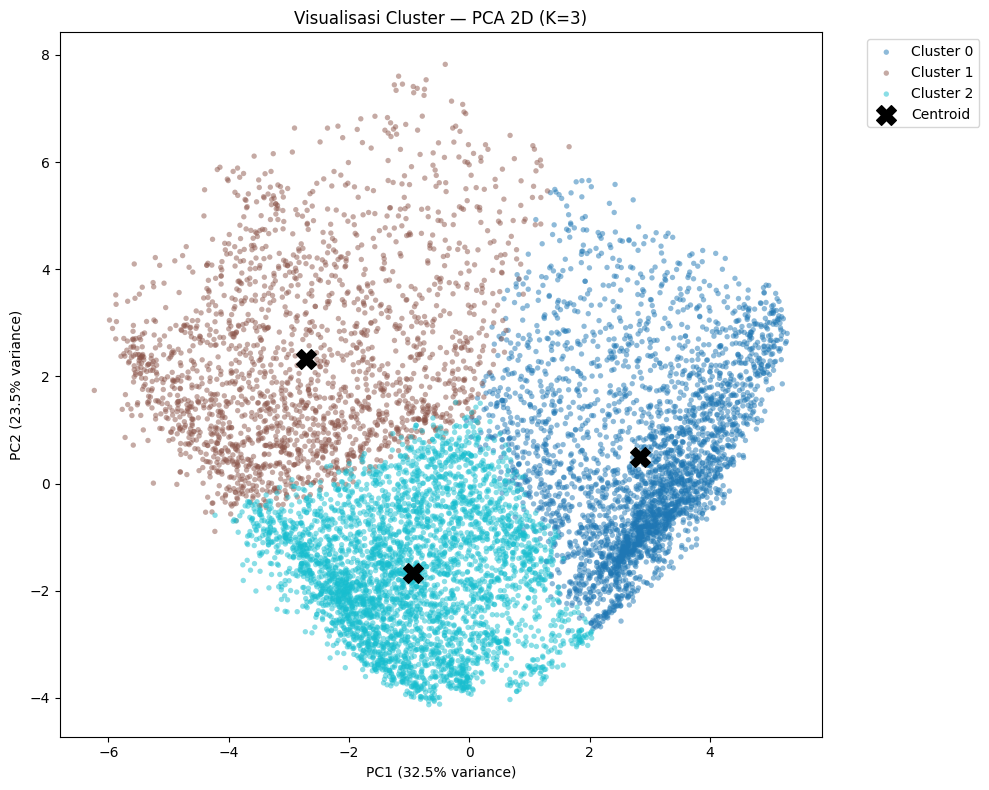

Variance explained PC1+PC2: 56.0%


In [28]:
# Gunakan best model (KMeans optimal) untuk visualisasi
best_labels = labels_km   # KMeans dengan K optimal
COLORS      = cm.tab10(np.linspace(0, 1, OPTIMAL_K))

# ============================================================
# PCA 2D
# ============================================================
pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 8))
for c in range(OPTIMAL_K):
    mask = best_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[COLORS[c]], label=f'Cluster {c}',
               alpha=0.5, s=15, edgecolors='none')

# Centroid
cents_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(cents_pca[:, 0], cents_pca[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroid')

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
ax.set_title(f'Visualisasi Cluster — PCA 2D (K={OPTIMAL_K})')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Variance explained PC1+PC2: {(var_exp[0]+var_exp[1])*100:.1f}%')

Running t-SNE pada 3000 sampel...


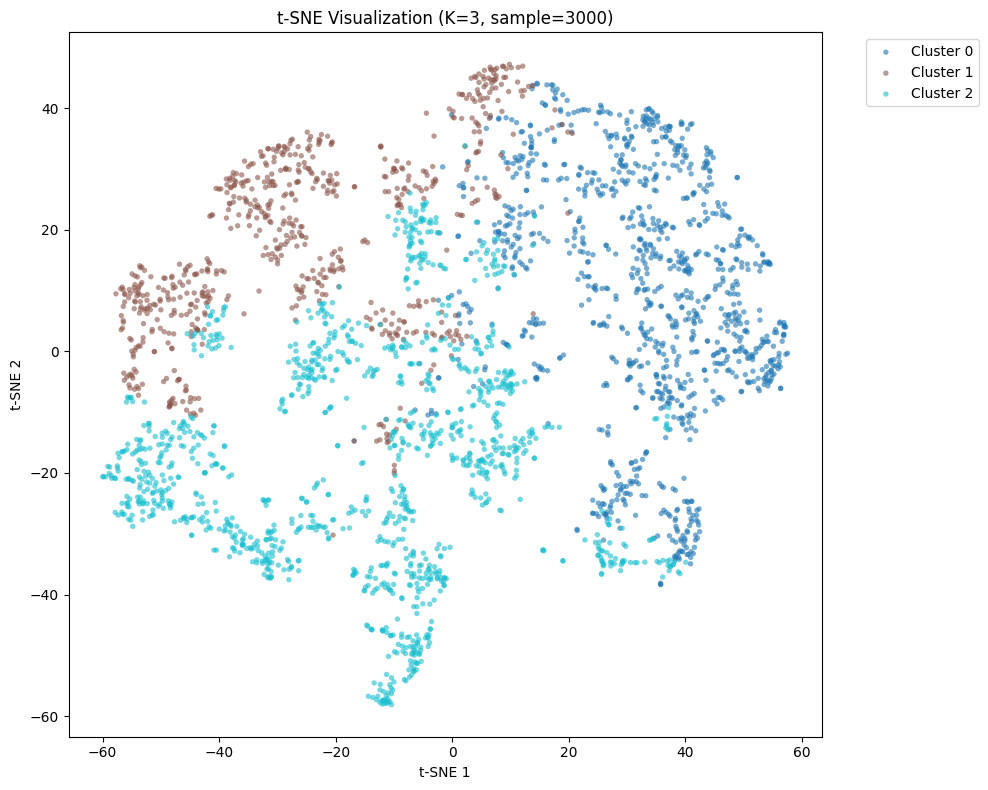

In [29]:
# ============================================================
# t-SNE 2D (lebih ekspresif untuk cluster)
# ============================================================
# Sample dulu agar tidak terlalu lama
tsne_size   = min(3000, len(X_scaled))
idx_sample  = np.random.choice(len(X_scaled), tsne_size, replace=False)
X_tsne_in   = X_scaled.values[idx_sample]
lbl_tsne    = best_labels[idx_sample]

print(f'Running t-SNE pada {tsne_size} sampel...')
tsne    = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne  = tsne.fit_transform(X_tsne_in)

fig, ax = plt.subplots(figsize=(10, 8))
for c in range(OPTIMAL_K):
    mask = lbl_tsne == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=[COLORS[c]], label=f'Cluster {c}',
               alpha=0.6, s=15, edgecolors='none')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f't-SNE Visualization (K={OPTIMAL_K}, sample={tsne_size})')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('tsne_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

## 👥 9. Interpretasi & Profil Tiap Cluster

In [30]:
# Tambahkan label cluster ke dataframe asli
df_profil = df_clean.copy()
df_profil['Cluster'] = best_labels

# Profil rata-rata per cluster
profile = df_profil.groupby('Cluster').mean().round(2)
print('=== Profil Rata-rata Tiap Cluster ===')
profile.T

=== Profil Rata-rata Tiap Cluster ===


Cluster,0,1,2
BALANCE,2260.19,1867.33,402.30
BALANCE_FREQUENCY,0.96,0.98,0.88
PURCHASES,166.50,2113.48,480.15
ONEOFF_PURCHASES,101.48,1041.01,199.33
INSTALLMENTS_PURCHASES,62.26,719.77,264.69
CASH_ADVANCE,1541.42,447.76,60.90
PURCHASES_FREQUENCY,0.16,0.89,0.55
ONEOFF_PURCHASES_FREQUENCY,0.07,0.50,0.12
PURCHASES_INSTALLMENTS_FREQUENCY,0.10,0.66,0.43
CASH_ADVANCE_FREQUENCY,0.28,0.08,0.02


In [31]:
# Ukuran tiap cluster
cluster_sizes = df_profil['Cluster'].value_counts().sort_index()
print('=== Ukuran Cluster ===')
for c, n in cluster_sizes.items():
    print(f'  Cluster {c}: {n:,} pelanggan ({n/len(df_profil)*100:.1f}%)')

=== Ukuran Cluster ===
  Cluster 0: 3,170 pelanggan (35.4%)
  Cluster 1: 2,017 pelanggan (22.5%)
  Cluster 2: 3,763 pelanggan (42.0%)


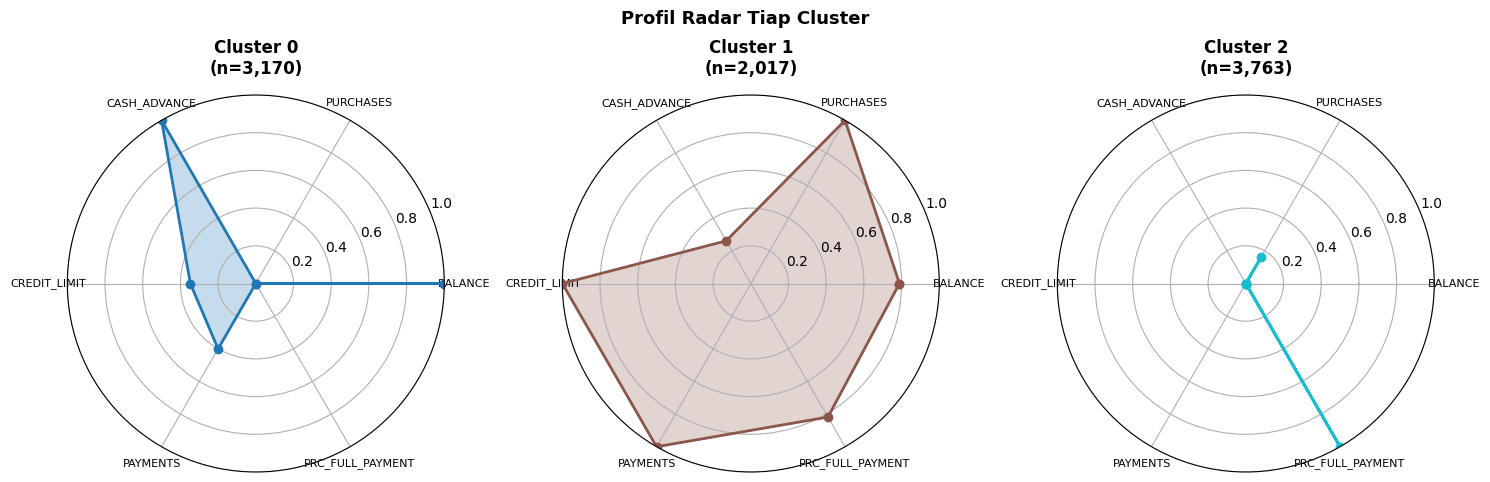

In [32]:
# Radar chart profil cluster (fitur utama)
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
                'PAYMENTS', 'PRC_FULL_PAYMENT']
key_features = [f for f in key_features if f in profile.columns]

# Normalisasi untuk radar (0-1)
profile_norm = profile[key_features].copy()
for col in key_features:
    mn, mx = profile_norm[col].min(), profile_norm[col].max()
    profile_norm[col] = (profile_norm[col] - mn) / (mx - mn + 1e-9)

N       = len(key_features)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, OPTIMAL_K,
                          figsize=(5*OPTIMAL_K, 5),
                          subplot_kw=dict(polar=True))
if OPTIMAL_K == 1: axes = [axes]

for c, ax in enumerate(axes):
    if c >= len(profile_norm): break
    vals  = profile_norm.iloc[c].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=COLORS[c])
    ax.fill(angles, vals, alpha=0.25, color=COLORS[c])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(key_features, size=8)
    ax.set_title(f'Cluster {c}\n(n={cluster_sizes.get(c, 0):,})',
                 fontweight='bold', pad=15)
    ax.set_ylim(0, 1)

plt.suptitle('Profil Radar Tiap Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_profile.png', dpi=100, bbox_inches='tight')
plt.show()

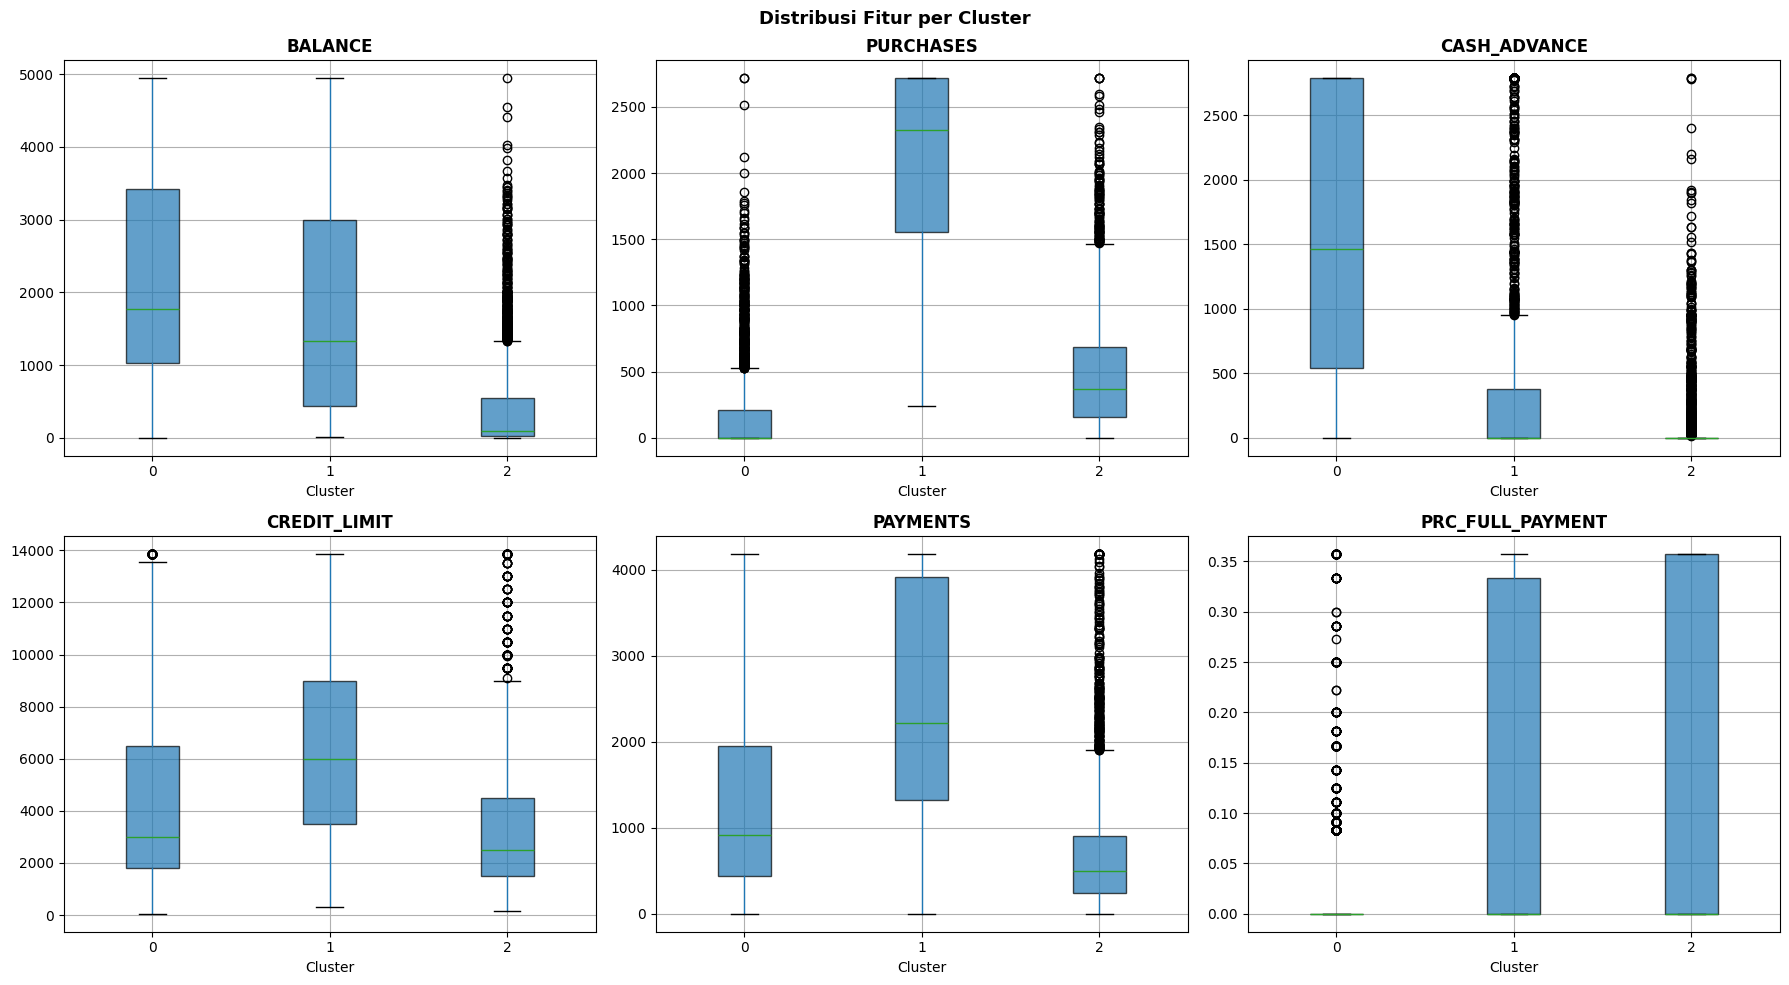

In [33]:
# Boxplot fitur utama per cluster
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features[:6]):
    df_profil.boxplot(column=col, by='Cluster', ax=axes[i],
                      patch_artist=True,
                      boxprops=dict(alpha=0.7))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Cluster')

plt.suptitle('Distribusi Fitur per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

## 📝 10. Kesimpulan & Interpretasi Cluster

In [34]:
best_model_row = df_results.iloc[0]

print('=' * 65)
print('KESIMPULAN — CUSTOMER CREDIT CARD CLUSTERING')
print('=' * 65)
print(f"""
Dataset      : clusteringmidterm.csv
Task         : Unsupervised Clustering
Jumlah fitur : {df_clean.shape[1]} (termasuk fitur engineered)

Preprocessing:
  - Drop CUST_ID (kolom ID)
  - Median Imputation untuk missing values
  - Feature Engineering: PAYMENT_RATIO, CASH_ADVANCE_RATIO,
    CREDIT_UTILIZATION, AVG_PURCHASE_PER_TRX
  - IQR Clip untuk outlier
  - StandardScaler (wajib untuk clustering berbasis jarak)

Penentuan K optimal:
  - Elbow Method, Silhouette Score,
    Davies-Bouldin, Calinski-Harabasz
  → K optimal: {OPTIMAL_K}

Model Clustering: K-Means, Hierarchical (Ward/Complete/Average),
                  DBSCAN
Tracking        : MLflow
Visualisasi     : PCA 2D, t-SNE, Radar Chart, Boxplot

🏆 Best Model  : {best_model_row['Model']}
   Silhouette  : {best_model_row['Silhouette']:.4f}
   Davies-Bouldin: {best_model_row['Davies_Bouldin']:.4f}
   N Clusters  : {int(best_model_row['N_Clusters'])}
""")

print('=== Deskripsi Tiap Cluster ===')
for c in range(OPTIMAL_K):
    row = profile.loc[c] if c in profile.index else None
    if row is None: continue
    n   = cluster_sizes.get(c, 0)
    bal = row.get('BALANCE', 0)
    pur = row.get('PURCHASES', 0)
    ca  = row.get('CASH_ADVANCE', 0)
    cl  = row.get('CREDIT_LIMIT', 0)
    pay = row.get('PRC_FULL_PAYMENT', 0)
    print(f'\nCluster {c} ({n:,} pelanggan):')
    print(f'  Balance avg       : {bal:,.0f}')
    print(f'  Purchases avg     : {pur:,.0f}')
    print(f'  Cash Advance avg  : {ca:,.0f}')
    print(f'  Credit Limit avg  : {cl:,.0f}')
    print(f'  Full Payment %    : {pay:.2%}')
    # Interpretasi sederhana
    if pur > profile['PURCHASES'].mean() * 1.5 and ca < profile.get('CASH_ADVANCE', pd.Series([0])).mean():
        print(f'  → 🛍️  Active Spender (banyak belanja, jarang cash advance)')
    elif ca > profile.get('CASH_ADVANCE', pd.Series([0])).mean() * 1.5:
        print(f'  → 💸  Cash Advance User (banyak tarik tunai)')
    elif bal < profile['BALANCE'].mean() * 0.5 and pay > 0.5:
        print(f'  → ✅  Responsible User (balance rendah, sering bayar penuh)')
    elif cl > profile['CREDIT_LIMIT'].mean() * 1.3:
        print(f'  → 💎  High Credit Limit Customer')
    else:
        print(f'  → 😴  Low Activity Customer (jarang transaksi)')

print('\n' + '=' * 65)

KESIMPULAN — CUSTOMER CREDIT CARD CLUSTERING

Dataset      : clusteringmidterm.csv
Task         : Unsupervised Clustering
Jumlah fitur : 21 (termasuk fitur engineered)

Preprocessing:
  - Drop CUST_ID (kolom ID)
  - Median Imputation untuk missing values
  - Feature Engineering: PAYMENT_RATIO, CASH_ADVANCE_RATIO,
    CREDIT_UTILIZATION, AVG_PURCHASE_PER_TRX
  - IQR Clip untuk outlier
  - StandardScaler (wajib untuk clustering berbasis jarak)

Penentuan K optimal:
  - Elbow Method, Silhouette Score,
    Davies-Bouldin, Calinski-Harabasz
  → K optimal: 3

Model Clustering: K-Means, Hierarchical (Ward/Complete/Average),
                  DBSCAN
Tracking        : MLflow
Visualisasi     : PCA 2D, t-SNE, Radar Chart, Boxplot

🏆 Best Model  : DBSCAN
   Silhouette  : 0.2623
   Davies-Bouldin: 0.7184
   N Clusters  : 43

=== Deskripsi Tiap Cluster ===

Cluster 0 (3,170 pelanggan):
  Balance avg       : 2,260
  Purchases avg     : 166
  Cash Advance avg  : 1,541
  Credit Limit avg  : 4,416
  Ful

In [35]:
# Simpan hasil & copy ke Google Drive
import shutil

df_results.to_csv('clustering_results.csv', index=False)
profile.to_csv('cluster_profiles.csv')
df_profil.to_csv('data_with_clusters.csv', index=False)
print('✅ CSV tersimpan')

OUTPUT_DRIVE = '/content/drive/MyDrive/clustering_dataset/output/'
os.makedirs(OUTPUT_DRIVE, exist_ok=True)

for f in [
    'clustering_results.csv', 'cluster_profiles.csv', 'data_with_clusters.csv',
    'feature_distributions.png', 'correlation_heatmap.png', 'boxplot_outliers.png',
    'scatter_eda.png', 'optimal_k.png', 'silhouette_plot.png', 'dendrogram.png',
    'kdistance_plot.png', 'model_comparison.png', 'pca_clusters.png',
    'tsne_clusters.png', 'radar_profile.png', 'cluster_boxplots.png'
]:
    if os.path.exists(f):
        shutil.copy(f, OUTPUT_DRIVE)
        print(f'  Copied: {f}')

print(f'\n✅ Semua output tersimpan di Drive: {OUTPUT_DRIVE}')

✅ CSV tersimpan
  Copied: clustering_results.csv
  Copied: cluster_profiles.csv
  Copied: data_with_clusters.csv
  Copied: feature_distributions.png
  Copied: correlation_heatmap.png
  Copied: boxplot_outliers.png
  Copied: scatter_eda.png
  Copied: optimal_k.png
  Copied: silhouette_plot.png
  Copied: dendrogram.png
  Copied: kdistance_plot.png
  Copied: model_comparison.png
  Copied: pca_clusters.png
  Copied: tsne_clusters.png
  Copied: radar_profile.png
  Copied: cluster_boxplots.png

✅ Semua output tersimpan di Drive: /content/drive/MyDrive/clustering_dataset/output/
